# April Code pudding Project (Youtube Sentiment Analysis)

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
import seaborn as sns
import re
import os


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob

from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu

import warnings
warnings.filterwarnings("ignore")




## Data Overview

In [2]:
# Reading the dataset
# Set the path to the dataset

dataset_path = os.path.join('..', 'datasets', 'archive')

comments = pd.read_csv(
    os.path.join(dataset_path, 'UScomments.csv'),
    on_bad_lines='skip',
    encoding='utf-8',
    low_memory=False
)
videos = pd.read_csv(
    os.path.join(dataset_path, 'USvideos.csv'), 
    on_bad_lines='skip', 
    encoding='utf-8')

In [3]:
display(comments.head(5)) # Display the first 5 rows of the comments DataFrame

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0


In [4]:
display(videos.head(5)) # Display the first 5 rows of the videos DataFrame

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,Logan Paul Vlogs,24,logan paul vlog|logan paul|logan|paul|olympics...,4394029,320053,5931,46245,https://i.ytimg.com/vi/XpVt6Z1Gjjo/default.jpg,13.09
1,K4wEI5zhHB0,iPhone X — Introducing iPhone X — Apple,Apple,28,Apple|iPhone 10|iPhone Ten|iPhone|Portrait Lig...,7860119,185853,26679,0,https://i.ytimg.com/vi/K4wEI5zhHB0/default.jpg,13.09
2,cLdxuaxaQwc,My Response,PewDiePie,22,[none],5845909,576597,39774,170708,https://i.ytimg.com/vi/cLdxuaxaQwc/default.jpg,13.09
3,WYYvHb03Eog,Apple iPhone X first look,The Verge,28,apple iphone x hands on|Apple iPhone X|iPhone ...,2642103,24975,4542,12829,https://i.ytimg.com/vi/WYYvHb03Eog/default.jpg,13.09
4,sjlHnJvXdQs,iPhone X (parody),jacksfilms,23,jacksfilms|parody|parodies|iphone|iphone x|iph...,1168130,96666,568,6666,https://i.ytimg.com/vi/sjlHnJvXdQs/default.jpg,13.09


In [5]:
# Display the shape of the comments DataFrame
display(comments.shape)

# Display the shape of the videos DataFrame
display(videos.shape)

(691400, 4)

(7992, 11)

In [6]:
# Display information about the comments DataFrame
comments.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691400 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691400 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691400 non-null  object
 3   replies       691400 non-null  object
dtypes: object(4)
memory usage: 21.1+ MB


In [7]:
# Display information about the videos DataFrame
videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7992 entries, 0 to 7991
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   video_id        7992 non-null   object 
 1   title           7992 non-null   object 
 2   channel_title   7992 non-null   object 
 3   category_id     7992 non-null   int64  
 4   tags            7992 non-null   object 
 5   views           7992 non-null   int64  
 6   likes           7992 non-null   int64  
 7   dislikes        7992 non-null   int64  
 8   comment_total   7992 non-null   int64  
 9   thumbnail_link  7992 non-null   object 
 10  date            7992 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 686.9+ KB


In [8]:
# Display descriptive statistics of the comments DataFrame
comments.describe() 

,video_id,comment_text,likes,replies
count,691400,691374,691400,691400
unique,2266,434075,1060,369
top,XpVt6Z1Gjjo,Lol,0,0
freq,800,310,563752,649366


In [9]:
# Display information about the videos DataFrame
videos.describe() 

,category_id,views,likes,dislikes,comment_total,date
count,7992.000000,7.992000e+03,7.992000e+03,7992.000000,7992.000000,7992.000000
mean,20.217718,9.390269e+05,3.449193e+04,1781.625000,4608.489740,16.094249
std,7.415525,2.148263e+06,9.136160e+04,10822.103125,20252.758016,7.677674
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,1.100000
25%,17.000000,9.686375e+04,1.907500e+03,67.000000,286.000000,11.100000
50%,23.000000,3.086115e+05,8.652500e+03,272.500000,1085.500000,16.595000
75%,25.000000,9.588758e+05,3.021350e+04,1013.000000,3462.750000,21.100000
max,43.000000,4.150067e+07,2.010366e+06,318404.000000,736179.000000,30.090000


## Explorating Data Analysis

### Missing Values

In [10]:
# Check for missing values in the comments DataFrame
(comments.isna().sum()) 

# Check for missing values in the videos DataFrame as a percentage
display(comments.isna().sum()/len(comments)) 

video_id        0.000000
comment_text    0.000038
likes           0.000000
replies         0.000000
dtype: float64

In [11]:
# Drop rows with missing values in the 'comment_text' column
comments.dropna(subset=['comment_text'], inplace=True)

In [12]:
# Check for missing values in the videos DataFrame
videos.isna().sum() 

video_id          0
title             0
channel_title     0
category_id       0
tags              0
views             0
likes             0
dislikes          0
comment_total     0
thumbnail_link    0
date              0
dtype: int64

### Duplicates 

In [13]:
# Check for duplicate rows in the comments DataFrame
comments_duplicates = comments.duplicated().sum() 

# Display the number of duplicate rows in the comments DataFrame
display(comments_duplicates)

219743

In [14]:
# Check for duplicate rows in the comments DataFrame
videos_duplicates = videos.duplicated().sum()

# Display the number of duplicate rows in the comments DataFrame
display(videos_duplicates) 

0

In [15]:
# Cleaning the text data in the 'comment_text' column 
# Define a function to clean the text data
def clear_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]","", text)
    text = text.split()
    return " ".join(text)



In [16]:
# Apply the clear_text function to the 'comment_text' column
comments['clean_text'] = comments['comment_text'].astype(str).apply(clear_text) 
comments= comments.drop(columns=['comment_text'])

# Display the first 5 rows of the comments DataFrame after cleaning
display(comments.head(5)) 


,video_id,likes,replies,clean_text
0,XpVt6Z1Gjjo,4,0,logan paul its yo big day
1,XpVt6Z1Gjjo,3,0,ive been following you from the start of your ...
2,XpVt6Z1Gjjo,3,0,say hi to kong and maverick for me
3,XpVt6Z1Gjjo,3,0,my fan attendance
4,XpVt6Z1Gjjo,3,0,trending


In [17]:
# Check for missing values
print(comments['clean_text'].isna().sum())  

0


In [18]:
## Set of English stop words
stop_words =  set(stopwords.words('english')) 

In [19]:
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer() 

def lemmatize(text):
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token not in stop_words]
    lemmas = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(lemmas)

In [20]:
# Apply the clear_text function to the 'comment_text' column
comments['lemmatize_text'] = comments['clean_text'].apply(lemmatize) 

# Display the first 10 rows of the comments DataFrame after lemmatization
display(comments['lemmatize_text'].head(10))

0                                logan paul yo big day
1          ive following start vine channel seen vlogs
2                                 say hi kong maverick
3                                       fan attendance
4                                             trending
5                                    trending ayyeeeee
6                                           end though
7                                             trending
8                          happy one year vlogaversary
9    shit brother may single handedly ruined youtub...
Name: lemmatize_text, dtype: object

In [21]:
# Display the first 5 rows of the comments DataFrame after cleaning
display(comments[['clean_text', 'lemmatize_text']].head(20))

,clean_text,lemmatize_text
0,logan paul its yo big day,logan paul yo big day
1,ive been following you from the start of your ...,ive following start vine channel seen vlogs
2,say hi to kong and maverick for me,say hi kong maverick
3,my fan attendance,fan attendance
4,trending,trending
5,on trending ayyeeeee,trending ayyeeeee
6,the end though,end though
7,trending,trending
8,happy one year vlogaversary,happy one year vlogaversary
9,you and your shit brother may have single hand...,shit brother may single handedly ruined youtub...


In [22]:
# Display the shape of the comments DataFrame after cleaning
comments.shape

(691374, 5)

In [23]:
# Calculate the like-dislike ratio
videos['like_dislike_ratio'] = videos['likes'] / (videos['likes'] + videos['dislikes']) 

# Display the first 5 rows of the like-dislike ratio
display(videos.head(5)) 

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,like_dislike_ratio
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,Logan Paul Vlogs,24,logan paul vlog|logan paul|logan|paul|olympics...,4394029,320053,5931,46245,https://i.ytimg.com/vi/XpVt6Z1Gjjo/default.jpg,13.09,0.981806
1,K4wEI5zhHB0,iPhone X — Introducing iPhone X — Apple,Apple,28,Apple|iPhone 10|iPhone Ten|iPhone|Portrait Lig...,7860119,185853,26679,0,https://i.ytimg.com/vi/K4wEI5zhHB0/default.jpg,13.09,0.874471
2,cLdxuaxaQwc,My Response,PewDiePie,22,[none],5845909,576597,39774,170708,https://i.ytimg.com/vi/cLdxuaxaQwc/default.jpg,13.09,0.935471
3,WYYvHb03Eog,Apple iPhone X first look,The Verge,28,apple iphone x hands on|Apple iPhone X|iPhone ...,2642103,24975,4542,12829,https://i.ytimg.com/vi/WYYvHb03Eog/default.jpg,13.09,0.846123
4,sjlHnJvXdQs,iPhone X (parody),jacksfilms,23,jacksfilms|parody|parodies|iphone|iphone x|iph...,1168130,96666,568,6666,https://i.ytimg.com/vi/sjlHnJvXdQs/default.jpg,13.09,0.994158


## Creating Sentiment Feature

In [24]:
# Function to get the sentiment polarity of a text 
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity 

# Apply the get_sentiment function to the 'lemmatize_text' column
comments['sentiment_score'] = comments['lemmatize_text'].apply(get_sentiment) 

# Assign sentiment labels based on the sentiment score
comments['sentiment_label'] = comments['sentiment_score'].apply(lambda x: 'positive' if x > 0 else 'negative')

In [25]:
# Group by video_id and calculate the sentiment label counts
sentiment_summary = comments.groupby('video_id')['sentiment_label'].value_counts(normalize=True).unstack().fillna(0) 

# Calculate the comment sentiment ratio
sentiment_summary['comment_sentiment_ratio'] = sentiment_summary['positive'] / (sentiment_summary['positive'] + sentiment_summary['negative']) 

In [26]:
# Merge the sentiment summary with the videos DataFrame
cv = videos.merge(sentiment_summary[['comment_sentiment_ratio']], on='video_id', how='inner') 

# Display the first 5 rows of the merged DataFrame
display(cv.head(5)) 

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,like_dislike_ratio,comment_sentiment_ratio
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,Logan Paul Vlogs,24,logan paul vlog|logan paul|logan|paul|olympics...,4394029,320053,5931,46245,https://i.ytimg.com/vi/XpVt6Z1Gjjo/default.jpg,13.09,0.981806,0.290000
1,cLdxuaxaQwc,My Response,PewDiePie,22,[none],5845909,576597,39774,170708,https://i.ytimg.com/vi/cLdxuaxaQwc/default.jpg,13.09,0.935471,0.334168
2,WYYvHb03Eog,Apple iPhone X first look,The Verge,28,apple iphone x hands on|Apple iPhone X|iPhone ...,2642103,24975,4542,12829,https://i.ytimg.com/vi/WYYvHb03Eog/default.jpg,13.09,0.846123,0.335000
3,sjlHnJvXdQs,iPhone X (parody),jacksfilms,23,jacksfilms|parody|parodies|iphone|iphone x|iph...,1168130,96666,568,6666,https://i.ytimg.com/vi/sjlHnJvXdQs/default.jpg,13.09,0.994158,0.352500
4,cMKX2tE5Luk,The Disaster Artist | Official Trailer HD | A24,A24,1,a24|a24 films|a24 trailers|independent films|t...,1311445,34507,544,3040,https://i.ytimg.com/vi/cMKX2tE5Luk/default.jpg,13.09,0.984480,0.391429


In [27]:
# Calculate the correlation between like-dislike ratio and comment sentiment ratio 
cv[['like_dislike_ratio', 'comment_sentiment_ratio']].corr()


,like_dislike_ratio,comment_sentiment_ratio
like_dislike_ratio,1.000000,0.282141
comment_sentiment_ratio,0.282141,1.000000


In [28]:
# Calculate the difference between the like-dislike ratio and the comment sentiment ratio
cv['ratio_diff'] = cv['like_dislike_ratio'] - cv['comment_sentiment_ratio']

# Sort the DataFrame by the ratio difference in descending order and sample 5 rows
cv.sort_values('ratio_diff', ascending=False).sample(5)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,like_dislike_ratio,comment_sentiment_ratio,ratio_diff
1006,rFFo-0v_vi4,WATERMELON FREAKSHAKE CUPCAKES- The Scran Line,The Scran Line,26,cupcakes|how to make vanilla cupcakes|over the...,56967,2541,47,196,https://i.ytimg.com/vi/rFFo-0v_vi4/default.jpg,18.09,0.981839,0.448622,0.533218
635,cOboLQMO4tQ,Sarah Huckabee Sanders on Jemele Hill,TP Clips 8,25,[none],162699,471,511,1287,https://i.ytimg.com/vi/cOboLQMO4tQ/default.jpg,16.09,0.479633,0.266892,0.212742
4969,UGUu7qhGh_k,WHEN SPONGEBOB IS LIFE,Mashd N Kutcher,10,mashd|mashed|mnk|dj|djs|aussie|australian|spon...,52776,3078,37,236,https://i.ytimg.com/vi/UGUu7qhGh_k/default.jpg,8.10,0.988122,0.285000,0.703122
3845,ALae1tWyTS8,"Hill, offense lead Dodgers' 10-0 victory: 9/27/17",MLB,17,sp:li=MLB|sp:ti:away=SD|sp:dt=2017-09-28T02:10...,25871,203,12,18,https://i.ytimg.com/vi/ALae1tWyTS8/default.jpg,2.10,0.944186,0.413793,0.530393
5972,Mhfg2lVpW8k,GoPro: Nate Adams - GoPro Kind of Day,GoPro,17,GoPro|Hero4|Hero5|Hero Camera|HD Camera|stoked...,105214,3841,75,202,https://i.ytimg.com/vi/Mhfg2lVpW8k/default.jpg,13.10,0.980848,0.363171,0.617676


In [29]:
# Checking the data types of the columns in the comments DataFrame and the shape of the DataFrame
comments.info()
comments.shape

<class 'pandas.core.frame.DataFrame'>
Index: 691374 entries, 0 to 691399
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   video_id         691374 non-null  object 
 1   likes            691374 non-null  object 
 2   replies          691374 non-null  object 
 3   clean_text       691374 non-null  object 
 4   lemmatize_text   691374 non-null  object 
 5   sentiment_score  691374 non-null  float64
 6   sentiment_label  691374 non-null  object 
dtypes: float64(1), object(6)
memory usage: 42.2+ MB


(691374, 7)

In [30]:
# Checking the data types of the columns in the videos DataFrame and the shape of the DataFrame
videos.info()
videos.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7992 entries, 0 to 7991
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   video_id            7992 non-null   object 
 1   title               7992 non-null   object 
 2   channel_title       7992 non-null   object 
 3   category_id         7992 non-null   int64  
 4   tags                7992 non-null   object 
 5   views               7992 non-null   int64  
 6   likes               7992 non-null   int64  
 7   dislikes            7992 non-null   int64  
 8   comment_total       7992 non-null   int64  
 9   thumbnail_link      7992 non-null   object 
 10  date                7992 non-null   float64
 11  like_dislike_ratio  7908 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 749.4+ KB


(7992, 12)

In [31]:
# Checking the data types of the columns in the merged DataFrame and the shape of the DataFrame
cv.info()
cv.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7723 entries, 0 to 7722
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   video_id                 7723 non-null   object 
 1   title                    7723 non-null   object 
 2   channel_title            7723 non-null   object 
 3   category_id              7723 non-null   int64  
 4   tags                     7723 non-null   object 
 5   views                    7723 non-null   int64  
 6   likes                    7723 non-null   int64  
 7   dislikes                 7723 non-null   int64  
 8   comment_total            7723 non-null   int64  
 9   thumbnail_link           7723 non-null   object 
 10  date                     7723 non-null   float64
 11  like_dislike_ratio       7705 non-null   float64
 12  comment_sentiment_ratio  7723 non-null   float64
 13  ratio_diff               7705 non-null   float64
dtypes: float64(4), int64(5),

(7723, 14)

In [32]:
# Checking for  missing values in the merged DataFrame
cv.isna().sum()

# Drop rows with missing values in the merged DataFrame
cv = cv.dropna() 

# Checking for missing values in the merged DataFrame after dropping rows with missing values
cv.isna().sum()

video_id                   0
title                      0
channel_title              0
category_id                0
tags                       0
views                      0
likes                      0
dislikes                   0
comment_total              0
thumbnail_link             0
date                       0
like_dislike_ratio         0
comment_sentiment_ratio    0
ratio_diff                 0
dtype: int64

### Do viewers express different opinions in the comments than they do with likes/dislikes?

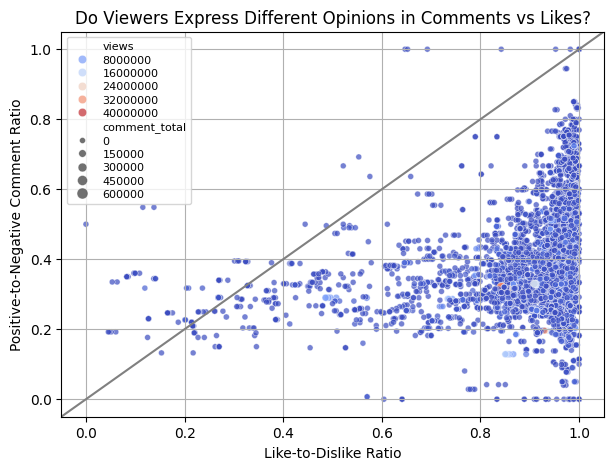

In [33]:
# Generating a scatter plot to visualize the relationship between like-dislike ratio and comment sentiment ratio
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=cv,
    x='like_dislike_ratio',
    
    y='comment_sentiment_ratio',
    size='comment_total',
    hue='views',
    palette='coolwarm',
    alpha=0.7
)
plt.axline((0, 0), slope=1, color='gray') 
plt.xlabel('Like-to-Dislike Ratio')
plt.ylabel('Positive-to-Negative Comment Ratio')
plt.title('Do Viewers Express Different Opinions in Comments vs Likes?')
plt.legend(loc='upper left', labelspacing=0.3, fontsize=8)
plt.grid(True)
plt.show()

#### Interpretation and Key Observations

1.  Most videos have high like to dislike ratio 
    - The majority of  points are lcustered on the right side (x > 0.8),  indicating that most videos recieve a high proportion of likes relative to dislikes. 
2. Comment Sentiment is generally lower
    - The majority of points fall below the diagonal line means thast the like to dislike ratio is higher than the positive to negative comment. This suggests that viewers that may have liked a video might have still leave more critical or mixed comments. Along with this, it also shows that like could reflect surface-level approval, whereas comments offer deeper insights, sometimes more critical.  
3. Videos with High Views (Red Dots) still show mixed comments. 
    - Also, high-view videos are below the diagonal, indicating that popularity doesn't guarantee overwhelmingly positive comment sentiment. This reflects that those videos might attract to a broad audience but may trigger critical  discussion in the comment section. 
4. Some outliers Exist
    - Among this huge dataset, there are few videos which have both high positive to negative comment ratios and very high likes to dislikes ratios.  



## Statistical Data Analysis

### Test the Hypothesis

#### Does a higher number of total views on a YouTube video lead to a significantly different like-to-dislike ratio?

HO = There is no correlation between total views and like/dislike ratio.

HA = There is a correlation between total views and like/dislike ratio.

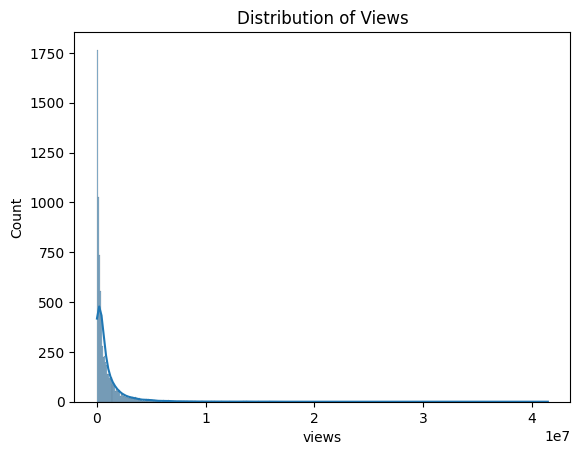

In [34]:
# Generating a histogram to visualize the distribution of views to check if they are normally distributed
sns.histplot(cv['views'], kde=True)
plt.title('Distribution of Views')
plt.show()


The above graph shows the distribution of the total views. The shape of the histogram is heavily right-skewed (positive skew) which suggests that most data points have low view counts. There is a small number of data points that have extremely high view counts (the long tail on the right). Thus, this data is not normally distributed. The distribution is highly asymmetric. 

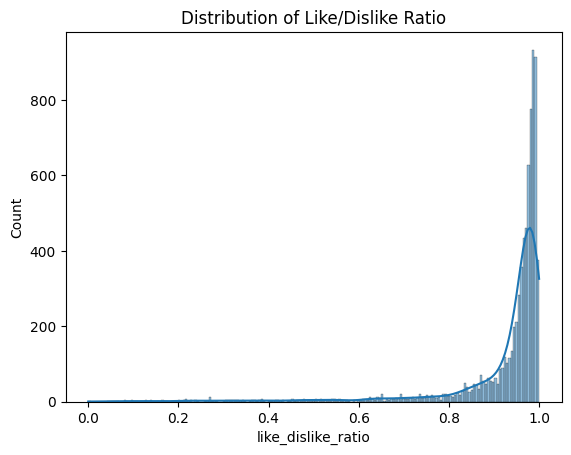

In [35]:
# Generating a histogram to visualize the distribution of likes dislike ratio to check if they are normally distributed
sns.histplot(cv['like_dislike_ratio'], kde=True)
plt.title('Distribution of Like/Dislike Ratio')
plt.show()

The above graph shows the distribution of the like dislike ratio. The histogram is left-skewed but concentrated closer to 1. There is a long tail toward lower ratios, indicating some videos have relatively more dislikes. Thus, this data is not normally distributed but distributed asymmetrically. 

In [36]:
# Doing a Spearman correlation test to check if there is a monotonic relationship between the two variables

# Set the significance level
alpha = 0.05

corr, p_value = spearmanr(cv['views'], cv['like_dislike_ratio'])

# Print the Spearman correlation
print(f"Spearman correlation: {corr:.3f}") 

# Print the p-value
print(f"p-value: {p_value}") 

# Check if the p-value is less than the significance level
if p_value < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

Spearman correlation: -0.030
p-value: 0.00857323755194233
We reject the null hypothesis


Spearman correlation is -0.030 which is very close to zero, meaning there is a very negative association between the views and like dislike ratio. This suggests that as views increases, like dislike ration tends to decrease very slightly but this trend is extremely weak. 

p-value is 0.0086 which tells us whether the observed correlation is statiscally significant. The p-value is less than 0.05, which means that the correlation is unlikely to have occured by random chance. As p-value is less than 0.05, we reject the null hypothesis. 

Conclusion: 

- Although the correlation is statistically significant, it is not practically significant. 
- The relationship between the views and like dislike ratio exists but is extremely weak. 
- So, while there is evidence that a relationship exists, it is not strong enough to be meaningful in real-world terms. 




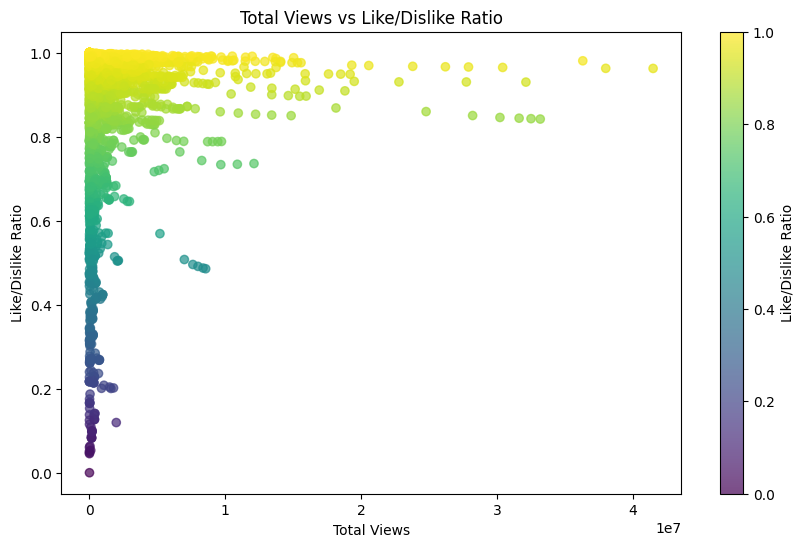

In [37]:
# Generating a scatter plot to visualize the relationship between views and like-dislike ratio
plt.figure(figsize=(10, 6))
plt.scatter(cv['views'], cv['like_dislike_ratio'], c=cv['like_dislike_ratio'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Like/Dislike Ratio')
plt.title('Total Views vs Like/Dislike Ratio')
plt.xlabel('Total Views')
plt.ylabel('Like/Dislike Ratio')
plt.show()

The above graph is a scatterplot to visualize the relationship between total views and like dislike ratio, with the color of each point representing the like dislike ratio. 

#### Interpretation and Key Observations 

1. Data Concentrated to the Left 
    - The majority of data  points are clustered on the left side representing that most videos don't go viral. Among those videos, like dislike ratio varies  widely. 

2. High View Counts has hight like dislike ratios
    - This means as the number of views increases, the like dislike ratio tends to get closer to 1. The yellow dots shows that videos with millions of views are almost mostly well-liked. 

3. Low like dislike ratios are rare in high view videos. 
    - It is rare to see a highly viewed video with low like dislike ratio. This suggests that poorly received content doesn't go viral.

#### Conclusion 

- Overall, there appears to be a positive relationship between total  views and like/dislike ratio, though not in terms of correlation but in the trend that popular videos tend to have higher like dislike ratios. 

- Popular videos are usually well-received. On the other side, less popular videos can be both poorly liked or well-liked which shows much more variability in like dislike ratio. 

- Videos tend to be likely shared and accumulate views if the videos are broadly liked. Conversely, content with poor like dislike ratios rarely accumulates high view counts. 

- Lastly, the skewed distribution of both variable is reflected here to and so one can see a dense cluster at low views and a thin spread ast high views. 


#### Does a higher number of total comments on a YouTube video lead to significantly different like-to-dislike ratios?

HO = There is no correlation between total number of comments and like/dislike ratio.

HA = There is a correlation between total number of comments and like/dislike ratio.

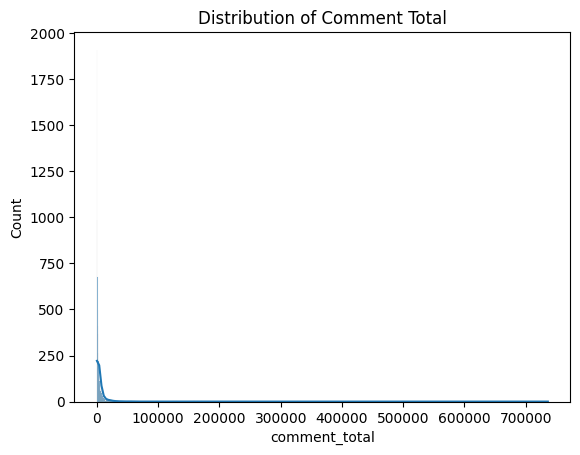

In [38]:
# Generating a histogram to visualize the distribution of comment total to check if they are normally distributed
sns.histplot(cv['comment_total'], kde=True)
plt.title('Distribution of Comment Total')
plt.show()

The above graph shows the distribution of the total comments. The shape of the histogram is heavily right-skewed (positive skew) which suggests that most data points have low number of total comments. There is a small number of data points that have extremely high number of comments (the long tail on the right). Thus, this data is not normally distributed. The distribution is highly asymmetric. 

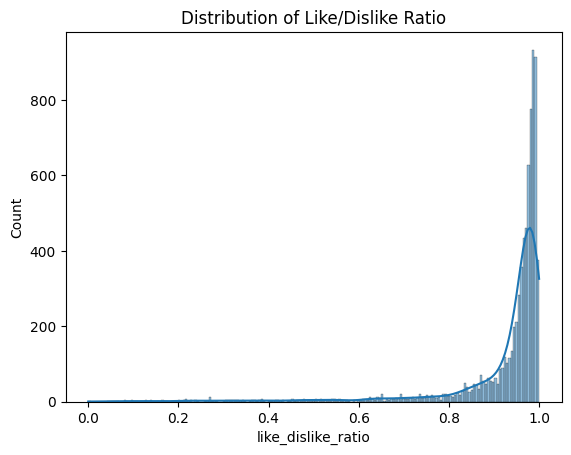

In [39]:
# Generating a histogram to visualize the distribution of like dislike ratio to check if they are normally distributed
sns.histplot(cv['like_dislike_ratio'], kde=True)
plt.title('Distribution of Like/Dislike Ratio')
plt.show()

The above graph shows the distribution of the like dislike ratio. The histogram is left-skewed but concentrated closer to 1. There is a long tail toward lower ratios, indicating some videos have relatively more dislikes. Thus, this data is not normally distributed but distributed asymmetrically. 

In [40]:
# Doing a Spearman correlation test to check if there is a monotonic relationship between the two variables
# Set the significance level
alpha = 0.05

# Calculate the Spearman correlation between comment total and like-dislike ratio
corr, p_value = spearmanr(cv['comment_total'], cv['like_dislike_ratio'])

# Print the Spearman correlation and p-value
print(f"Spearman correlation: {corr:.3f}") 
print(f"p-value: {p_value}")  

# Check if the p-value is less than the significance level
if p_value < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

Spearman correlation: 0.062
p-value: 4.1303412514170865e-08
We reject the null hypothesis


Spearman correlation is 0.062 which is very close to zero, meaning there is a very weak positive association between the total comments and like dislike ratio. This suggests that as total comments increases, like dislike ratio tends to increase very slightly but this trend is extremely weak. 

p-value is 4.13*e-08 which tells us whether the observed correlation is statiscally significant. The p-value is extremely small than 0.05, which means that the correlation is unlikely to have occured by random chance. As p-value is less than 0.05, we reject the null hypothesis. 

Conclusion: 

- Although the correlation is statistically significant, it is not practically significant. 
- The relationship between the total comments and like dislike ratio exists but is extremely weak. 
- So, while there is evidence that a relationship exists, it is not strong enough to be meaningful in real-world terms. 

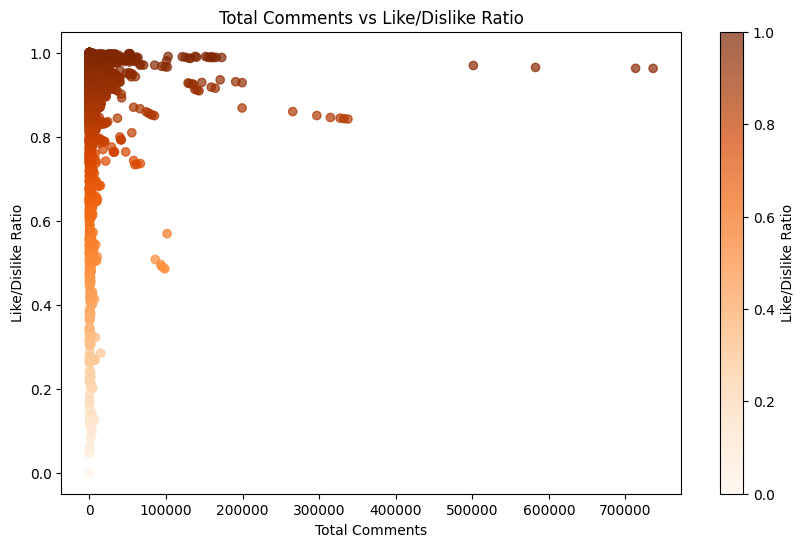

In [41]:
# Generating a scatter plot to visualize the relationship between total comments and like-dislike ratio
plt.figure(figsize=(10, 6))
plt.scatter(cv['comment_total'], cv['like_dislike_ratio'], c=cv['like_dislike_ratio'], cmap='Oranges', alpha=0.7)
plt.colorbar(label='Like/Dislike Ratio')
plt.title('Total Comments vs Like/Dislike Ratio')
plt.xlabel('Total Comments')
plt.ylabel('Like/Dislike Ratio')
plt.show()

#### Does a higher number of total views on a YouTube video lead to a significantly different comment sentiment ratio?



HO = There is no correlation between total views and comment sentiment ratio. 

HA = There is a correlation between total views and comment sentiment ratio.


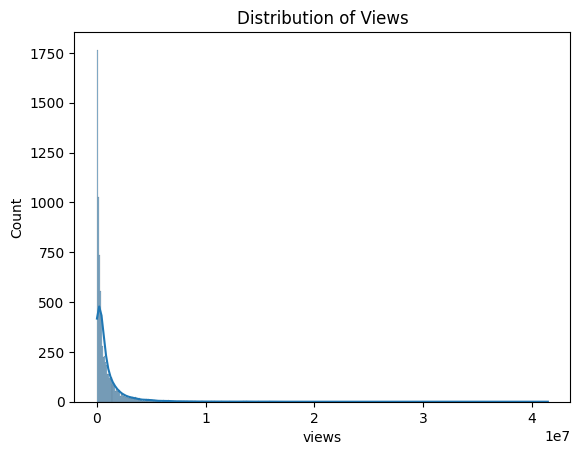

In [42]:
# Generating a histogram to visualize the distribution of views to check if they are normally distributed
sns.histplot(cv['views'], kde=True)
plt.title('Distribution of Views')
plt.show()


The above graph shows the distribution of the total views. The shape of the histogram is heavily right-skewed (positive skew) which suggests that most data points have low view counts. There is a small number of data points that have extremely high view counts (the long tail on the right). Thus, this data is not normally distributed. The distribution is highly asymmetric. 

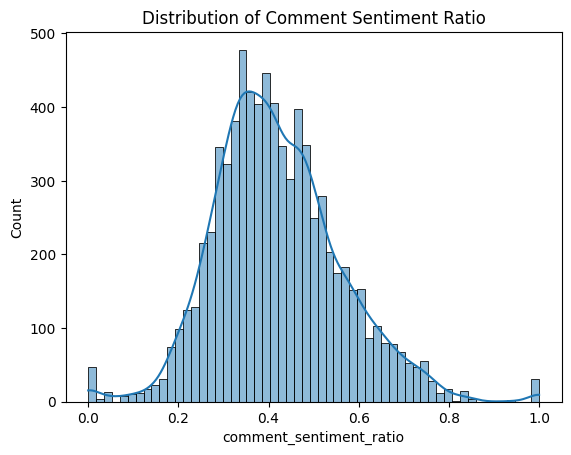

In [43]:
# Generating a histogram to visualize the distribution of comment sentiment ratio to check if they are normally distributed
sns.histplot(cv['comment_sentiment_ratio'], kde=True)
plt.title('Distribution of Comment Sentiment Ratio')
plt.show()

The above histogram shows the distribution of comment sentiment ratios. The distribution visually resembles a normal distribution but it is not normal rather their is slight right skewness with a tendency toward mildly positive or neutral sentiment. There are few comments with very high or low sentiment indicating that strongly negative or strongly positive comments are less common. 

In [44]:
# Doing a Spearman correlation test to check if there is a monotonic relationship between the two variables
# Set the significance level
alpha = 0.05

# Calculate the Spearman correlation between views and comment sentiment ratio
corr, p_value = spearmanr(cv['views'], cv['comment_sentiment_ratio'])

# Print the Spearman correlation and p-value
print(f"Spearman correlation: {corr:.3f}") 
print(f"p-value: {p_value}")  

# Check if the p-value is less than the significance level
if p_value < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

Spearman correlation: -0.247
p-value: 2.5611480810470882e-107
We reject the null hypothesis


Spearman correlation is -0.247 which is close to zero, meaning there is a negative association between the views and comment sentiment ratio. This suggests that as views increases, comment sentiment ratio tends to decrease but this trend is stronger than views and comments relationships with like dislike ratio. 

p-value is 2.56*e-107 which tells us whether the observed correlation is statiscally significant. The p-value is less than 0.05, which means that it is extremely statistically significant. As p-value is less than 0.05, we reject the null hypothesis. 

Conclusion: 

- The correlation is statistically significant, but there is moderately negative relationship between these two variables. 
- So, this result is likely meaningful, both practically and statiscally. 

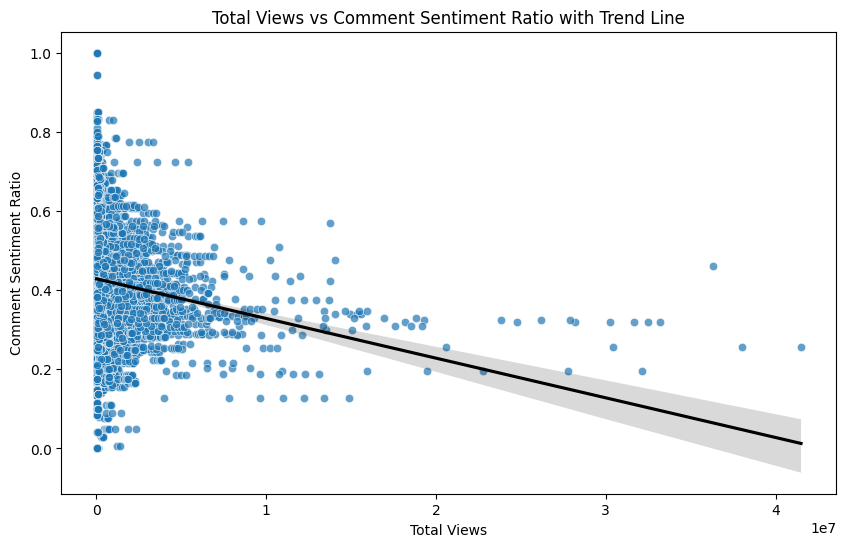

In [45]:
# Generating a scatter plot to visualize the relationship between views and comment sentiment ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='views', y='comment_sentiment_ratio', data=cv, alpha=0.7)
sns.regplot(x='views', y='comment_sentiment_ratio', data=cv, scatter=False, color='black', line_kws={"color": "black"})
plt.title('Total Views vs Comment Sentiment Ratio with Trend Line')
plt.xlabel('Total Views')
plt.ylabel('Comment Sentiment Ratio')
plt.show()

#### Does a higher number of total comments on a YouTube video lead to significantly different comment sentiment ratios?

HO = There is no correlation between total number of comments and comment sentiment ratio. 

HA = There is a correlation between total number of comments and comment sentiment ratio.

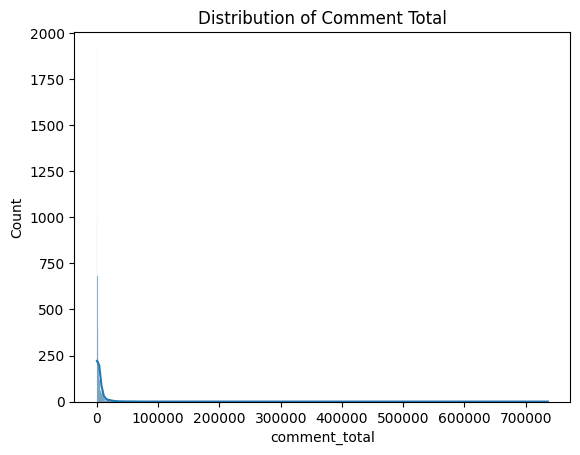

In [57]:
# Generating a histogram to visualize the distribution of comment total to check if they are normally distributed
sns.histplot(cv['comment_total'], kde=True)
plt.title('Distribution of Comment Total')
plt.show()


The above graph shows the distribution of the total comments. The shape of the histogram is heavily right-skewed (positive skew) which suggests that most data points have low number of total comments. There is a small number of data points that have extremely high number of comments (the long tail on the right). Thus, this data is not normally distributed. The distribution is highly asymmetric. 

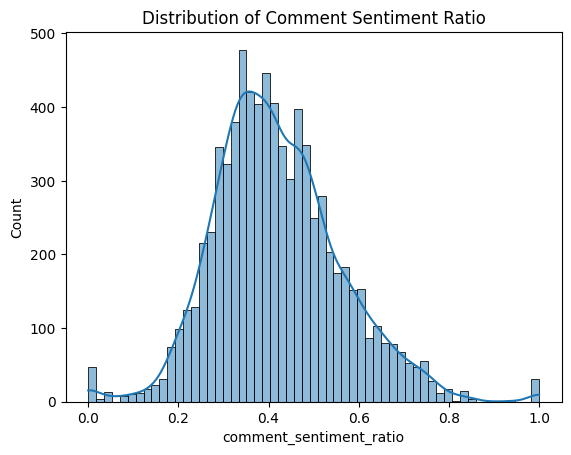

In [58]:
# Generating a histogram to visualize the distribution of comment sentiment ratio to check if they are normally distributed
sns.histplot(cv['comment_sentiment_ratio'], kde=True)
plt.title('Distribution of Comment Sentiment Ratio')
plt.show()

The above histogram shows the distribution of comment sentiment ratios. The distribution visually resembles a normal distribution but it is not normal rather their is slight right skewness with a tendency toward mildly positive or neutral sentiment. There are few comments with very high or low sentiment indicating that strongly negative or strongly positive comments are less common. 

In [47]:
# Doing a Spearman correlation test to check if there is a monotonic relationship between the two variables
# Set the significance level
alpha = 0.05

# Calculate the Spearman correlation between comment total and comment sentiment ratio
corr, p_value = spearmanr(cv['comment_total'], cv['comment_sentiment_ratio'])

# Print the Spearman correlation and p-value
print(f"Spearman correlation: {corr:.3f}") 
print(f"p-value: {p_value}")

# Check if the p-value is less than the significance level
if p_value < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

Spearman correlation: -0.184
p-value: 1.1063280575183414e-59
We reject the null hypothesis


Spearman correlation is -0.184 which is close to zero, meaning there is a negative association between the total comments and comment sentiment ratio. This suggests that as total comments increases, comment sentiment ratio tends to decrease but this trend is still relatively weak. 

p-value is 1.11*e-59 which tells us whether the observed correlation is highly statiscally significant. The p-value is less than 0.05, which means that it is+ statistically significant. As p-value is less than 0.05, we reject the null hypothesis. 

Conclusion: 

- The correlation is statistically significant, but there is moderately stronger negative relationship between these two variables. 
- So, this result is likely meaningful, and may have practical and statiscal relevance. 

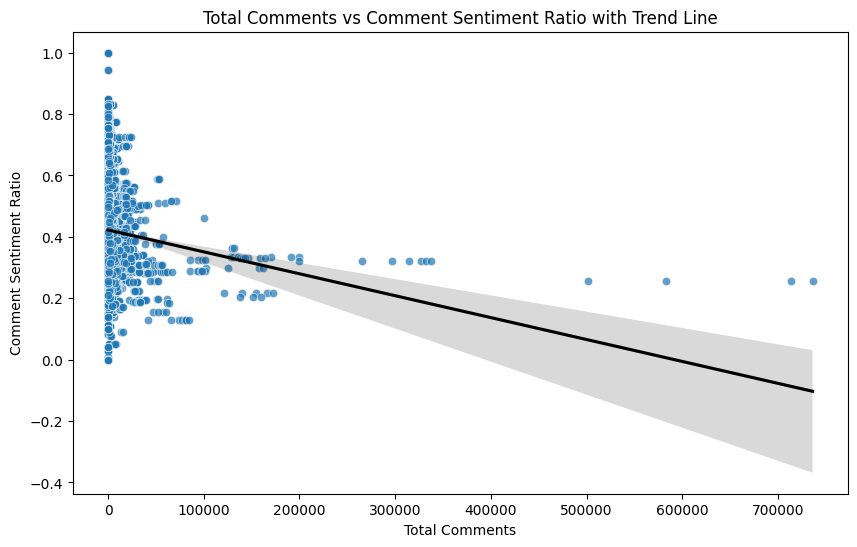

In [48]:
# Generating a scatter plot to visualize the relationship between comments and comment sentiment ratio 
plt.figure(figsize=(10, 6))
sns.scatterplot(x='comment_total', y='comment_sentiment_ratio', data=cv, alpha=0.7)
sns.regplot(x='comment_total', y='comment_sentiment_ratio', data=cv, scatter=False, color='black', line_kws={"color": "black"})
plt.title('Total Comments vs Comment Sentiment Ratio with Trend Line')
plt.xlabel('Total Comments')
plt.ylabel('Comment Sentiment Ratio')
plt.show()

#### Does longer comments are more likely to be positive than negative sentiment?

HO: The median comment length for positive sentiment is equal to the median comment length for negative sentiment.

HA: The median comment length for positive sentiment is greater than the median comment length for negative sentiment.

In [49]:
# Creating a new column in the cv DataFrame to store the sentiment score and sentiment. 
cv['sentiment_score'] = comments['sentiment_score']
cv['sentiment'] = comments['sentiment_score'].apply(lambda x: 'Positive' if x > 0 else 'Negative')



In [50]:
# Creating new columns in the cv DataFrame to store the comment length and word length
cv['comment_length'] = comments['clean_text'].apply(len)
cv['comment_word_length'] = comments['clean_text'].apply(lambda x: len(x.split()))

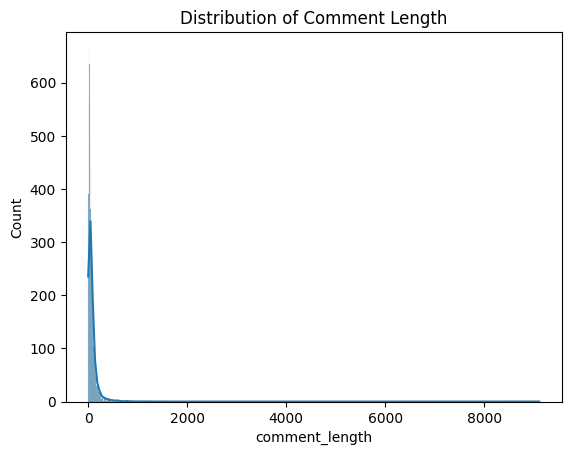

In [59]:
# Generating a histogram to visualize the distribution of comment length to check if they are normally distributed
sns.histplot(cv['comment_length'], kde=True)
plt.title('Distribution of Comment Length')
plt.show()


The above graph shows the distribution of the comments length. The shape of the histogram is heavily right-skewed (positive skew) which suggests that most data points have small comments. There is a small number of data points that have extremely long comments (the long tail on the right). Thus, this data is not normally distributed. The distribution is highly asymmetric. 

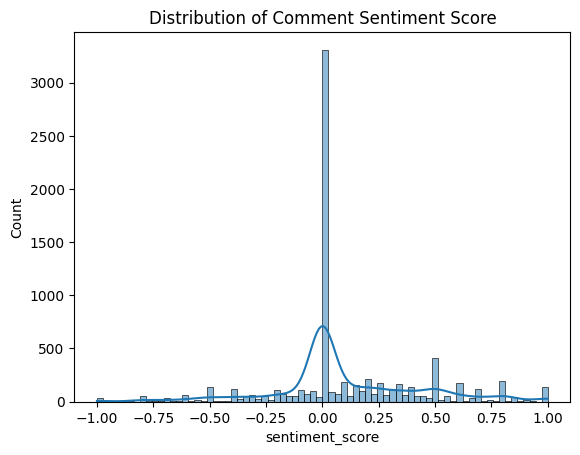

In [61]:
# Generating a histogaram to visualize the distribution of sentiment score to check if they are normally distributed
sns.histplot(cv['sentiment_score'], kde=True)
plt.title('Distribution of Comment Sentiment Score')
plt.show()

In [52]:
#  Check for missing values in the cv DataFrame
cv.isna().sum() 

# Drop rows with missing values in the cv DataFrame
cv  = cv.dropna() 

# Check for missing values in the cv DataFrame after dropping rows with missing values
cv.isna().sum()

video_id                   0
title                      0
channel_title              0
category_id                0
tags                       0
views                      0
likes                      0
dislikes                   0
comment_total              0
thumbnail_link             0
date                       0
like_dislike_ratio         0
comment_sentiment_ratio    0
ratio_diff                 0
sentiment_score            0
sentiment                  0
comment_length             0
comment_word_length        0
dtype: int64

In [53]:
# Filter for positive comments
positive_comments = cv[cv['sentiment'] == 'Positive']['comment_length']

# Filter for negative comments
negative_comments = cv[cv['sentiment'] == 'Negative']['comment_length']

In [56]:
# Perform the Mann-Whitney U test
# Set the significance level
alpha = 0.05

# Perform the Mann-Whitney U test to compare the distributions of positive and negative comments
stat, p = mannwhitneyu(positive_comments, negative_comments, alternative='two-sided')

# Print the Mann-Whitney U test statistic and p-value
print(f"Mann-Whitney U test statistic: {stat:.3f}") 
print(f"p-value: {p}")


# Check if the p-value is less than the significance level
if p < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

Mann-Whitney U test statistic: 9060790.000
p-value: 4.295065660136684e-91
We reject the null hypothesis


p-value is 4.30*e-91 is far below 0.05, so reject the null hypothesis. This means that there is statistically significant difference between the two groups. 

Conclusion: 

- Both positive and negative groups in terms of comments length are significantly  different in their distributions.
There is a strong evidence that one group tends to have higher or lower values than the other. 

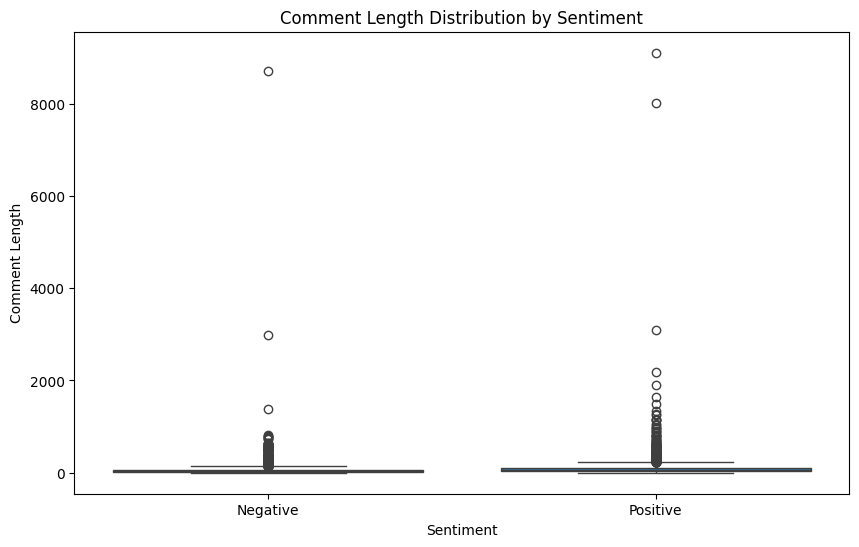

In [55]:
# Generating a box plot to visualize the distribution of comment length by sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='comment_length', data=cv)
plt.title('Comment Length Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Comment Length')
plt.show()
